In [3]:
#Generating a corpus from Marathi Wikipedia pages

from datasets import load_dataset

dataset = load_dataset("wikimedia/wikipedia", "20231101.mr", split="train")

with open("marathi_corpus.txt", "w", encoding="utf-8") as f:
    for ex in dataset:
        f.write(ex["text"].strip() + "\n")

print(f"Total articles: {len(dataset)}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

20231101.mr/train-00000-of-00001.parquet:   0%|          | 0.00/82.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/94133 [00:00<?, ? examples/s]

Total articles: 94133


In [4]:
#Text normalization

import unicodedata
import re

MARATHI_STOPWORDS = set([
    'आहे', 'आहेत', 'होते', 'होता', 'होती', 'आणि', 'हे', 'हा', 'ही',
    'या', 'त्या', 'ते', 'तो', 'ती', 'एक', 'की', 'का', 'काय', 'पण',
    'तर', 'मात्र', 'म्हणून', 'म्हणजे', 'जे', 'जो', 'जी', 'व', 'अन्',
    'नाही', 'नव्हते', 'असे', 'असा', 'अशी', 'येथे', 'तेथे', 'केले',
    'केली', 'केला', 'झाले', 'झाला', 'झाली', 'असून', 'येत', 'जात',
    'मी', 'तू', 'आम्ही', 'तुम्ही', 'आपण', 'त्यांनी', 'त्याने',
    'त्यांचे', 'त्याचे', 'त्यांचा', 'त्याचा', 'यांनी', 'याने',
    'सर्व', 'काही', 'कोण', 'कुठे', 'कसे', 'किती', 'कधी',
    'त्यात', 'यात', 'असल्याने', 'असलेल्या', 'असलेला', 'असलेली'
])

NUKTA = '\u093C'
NUKTA_DECOMPOSITIONS = [
    ('\u0929', '\u0928' + NUKTA),
    ('\u0931', '\u0930' + NUKTA),
    ('\u0934', '\u0933' + NUKTA),
    ('\u0958', '\u0915' + NUKTA),
    ('\u0959', '\u0916' + NUKTA),
    ('\u095A', '\u0917' + NUKTA),
    ('\u095B', '\u091C' + NUKTA),
    ('\u095C', '\u0921' + NUKTA),
    ('\u095D', '\u0922' + NUKTA),
    ('\u095E', '\u092B' + NUKTA),
    ('\u095F', '\u092F' + NUKTA),
]

PUNCTUATION_NORMALIZATIONS = [
    ('\uFEFF', ''),
    ('„',  '"'),
    ('\u201C', '"'),
    ('\u201D', '"'),
    ('–',  '-'),
    ('—',  ' - '),
    ('´',  "'"),
    ('\u2018', "'"),
    ('‚',  "'"),
    ('\u2019', "'"),
    ("''", '"'),
    ('´´', '"'),
    ('…',  '...'),
]

def is_devanagari_word(word):
    if not word:
        return False
    devanagari_chars = sum(1 for c in word if '\u0900' <= c <= '\u097F')
    return devanagari_chars / len(word) >= 0.5

def normalize_marathi(text, remove_stopwords=False, remove_nuktas=False):

    text = unicodedata.normalize('NFC', text)

    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)

    text = re.sub(r'&nbsp;|&amp;|&lt;|&gt;|&quot;', ' ', text)
    text = re.sub(r'<[^>]+>', '', text)

    for src, tgt in PUNCTUATION_NORMALIZATIONS:
        text = text.replace(src, tgt)

    text = text.replace('\uFEFF', '')
    text = text.replace('\uFFFE', '')
    text = text.replace('\u2060', '')
    text = text.replace('\u00AD', '')
    text = text.replace('\u200C', '')
    text = text.replace('\u200D', '')
    text = text.replace('\u200B', ' ')
    text = text.replace('\u00A0', ' ')

    text = text.replace('\u0972', '\u090F')

    for composed, decomposed in NUKTA_DECOMPOSITIONS:
        text = text.replace(composed, decomposed)

    if remove_nuktas:
        text = text.replace(NUKTA, '')

    text = text.replace('\u007C', '\u0964')

    text = re.sub(r'([\u0900-\u097F]):', r'\1' + '\u0903', text)

    devanagari_digits = '०१२३४५६७८९'
    ascii_digits = '0123456789'
    for deva, asc in zip(devanagari_digits, ascii_digits):
        text = text.replace(deva, asc)

    text = re.sub(r'।+', '।', text)
    text = re.sub(r'\s*।\s*', ' । ', text)

    words = text.split()
    filtered_words = [w for w in words if is_devanagari_word(w.strip('।.,:;!?()[]{}"\'-'))]
    text = ' '.join(filtered_words)

    text = re.sub(r'[^\u0900-\u097F\s0-9।,.!?\-]', '', text)

    if remove_stopwords:
        words = text.split()
        text = ' '.join(w for w in words if w not in MARATHI_STOPWORDS)

    text = re.sub(r'[ \t]+', ' ', text)
    text = re.sub(r'\n+', '\n', text)
    text = '\n'.join(line.strip() for line in text.splitlines())
    text = '\n'.join(line for line in text.splitlines() if line.strip())

    return text


normalized_lines = []
skipped = 0

with open("marathi_corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        normalized = normalize_marathi(line.strip())
        if len(normalized.split()) < 3:
            skipped += 1
            continue
        normalized_lines.append(normalized)

with open("marathi_corpus_normalized.txt", "w", encoding="utf-8") as f:
    f.write('\n'.join(normalized_lines))

print(f"Lines kept:    {len(normalized_lines):,}")
print(f"Lines skipped: {skipped:,}")

Lines kept:    608,586
Lines skipped: 1,226,050


In [5]:
# Text normalization of the Marathi corpus

normalized_lines = []
skipped = 0

with open("marathi_corpus.txt", "r", encoding="utf-8") as f:
    for line in f:
        normalized = normalize_marathi(line.strip())
        if len(normalized.split()) < 3:
            skipped += 1
            continue
        normalized_lines.append(normalized)

with open("marathi_corpus_normalized.txt", "w", encoding="utf-8") as f:
    f.write('\n'.join(normalized_lines))

print(f"Lines kept:    {len(normalized_lines):,}")
print(f"Lines skipped: {skipped:,}")

Lines kept:    608,586
Lines skipped: 1,226,050


In [6]:
#Looking at a sample of the original vs. normalised corpus

print("ORIGINAL")
with open("marathi_corpus.txt", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 20:
            break
        print(f"{i+1}: {line.strip()}")

print("\nNORMALIZED")
with open("marathi_corpus_normalized.txt", "r", encoding="utf-8") as f:
    for i, line in enumerate(f):
        if i >= 20:
            break
        print(f"{i+1}: {line.strip()}")

ORIGINAL
1: ॥ औदुंबर रसग्रहण ॥
2: 
3: एखाद्या कुशल चित्रकाराने कुंचल्याच्या अवघ्या चार-सहा फटकाऱ्यांसरशी एखादे सुरेख चित्र निर्माण करावे तद्वत अवघ्या आठ ओळीत बालकवींनी एक सुंदर निसर्गचित्र शब्दांच्या कुंचल्याने या कवितेत रेखाटलेले आहे. हे चित्र रंगविताना कवीने विविध रंग वापरलेले आढळतील. निळासावळा झरा, शेतमळ्यांची हिरवी गरदी, पांढरी पायवाट व काळा डोह-मोजक्या रंगांनी शब्दांच्या चौकटीत बसविलेले हे एक साधे व जिवंत चित्र आहे. बालकवींची रंगदृष्टी येथे आपल्या प्रत्ययास येते.
4: 
5: पहिल्या चार ओळींत टेकड्या, गाव, शेतमळे व झरा यांनी व्यापलेले विहंगम दृश्य दिसते.
6: 
7: शेतमळ्यांच्या हिरव्या गरदीतून वाहणाऱ्या निळ्यासावळ्या झऱ्यावरून जी नजर मागे जाते ती चार घरांचे चिमुकले गाव ओलांडून पैल टेकडीपर्यंत पोचते. केवढा विस्तीर्ण पट कवीने पार्श्वभूमीसाठी घेतलेला आहे! पुढील दोन ओळीत त्या काळ्या डोहाच्या लाटांवर गोड काळिमा पसरून जळात पाय टाकून बसलेला औदुंबर दाखविला आहे.
8: 
9: केवळ निसर्गाचे एक सुरम्य चित्र रंगविण्याचा कवीचा हेतू दिसत नाही. पहिल्या चार ओळींतील आनंदी व खेळकर वृत्तीच्या पार्श्वभूमीवर नैराश्

In [7]:
# Using SentencePiece (a language-independent subword tokenizer) to implement the BPE and ULM models

import sentencepiece as spm

# Training the BPE tokenizer on the normalized corpus
spm.SentencePieceTrainer.train(
    input='marathi_corpus_normalized.txt',
    model_prefix='marathi_bpe',
    vocab_size=16000,
    model_type='bpe',
    character_coverage=0.9995
)
print("BPE Tokenizer - run completed")

# Trainining the Unigram tokenizer on the normalized corpus
spm.SentencePieceTrainer.train(
    input='marathi_corpus_normalized.txt',
    model_prefix='marathi_unigram',
    vocab_size=16000,
    model_type='unigram',
    character_coverage=0.9995
)
print("Unigram Tokenizer - run completed")

BPE Tokenizer - run completed
Unigram Tokenizer - run completed


In [8]:
import sentencepiece as spm
import pandas as pd

class TokenizerEvaluator:
    def __init__(self, model_path):
        self.sp = spm.SentencePieceProcessor(model_file=model_path)

    def evaluate(self, text, gold_standard=None):
        """
        Calculates the following intrinsic evaluation metrics on the normalized
        text: Fertility Score, Characters Per Token, and
        Word Fragmentation Rate

        """
        words = text.split()

        total_tokens = 0
        total_chars = 0
        fragmented_count = 0

        for word in words:
            tokens = self.sp.encode_as_pieces(word)
            num_tokens = len(tokens)

            total_tokens += num_tokens
            total_chars += len(word)

            # Word Fragmentation
            if num_tokens > 1:
                fragmented_count += 1

        # Metric Calculations
        metrics = {
            "Fertility Score": total_tokens / len(words),
            "Characters per Token": total_chars / total_tokens,
            "Word Fragmentation Rate (%)": (fragmented_count / len(words)) * 100,
        }

        return metrics

evaluator = TokenizerEvaluator('marathi_bpe.model')
sample_text = "शिक्षकाने मुलाला घरात बोलावले आणि तो जाणार म्हणाला"

results = evaluator.evaluate(sample_text)

evaluator = TokenizerEvaluator('marathi_unigram.model')
sample_text = "शिक्षकाने मुलाला घरात बोलावले आणि तो जाणार म्हणाला"

results = evaluator.evaluate(sample_text)

BPE vocab size       : 15,997
Unigram vocab size   : 15,997
Shared tokens        : 10,770
BPE only             : 5,227
Unigram only         : 5,227
Overlap (Jaccard)    : 0.5074
Overlap % of BPE     : 67.33%
Overlap % of Unigram : 67.33%

Average token length (BPE)    : 5.76 chars
Average token length (Unigram): 6.44 chars

Sample SHARED tokens (appear in both):
['▁स्थापने', 'ाहून', 'जण', '▁चित्रपटाने', '▁गंगाखेड', '▁कुळ', '▁अधिवेशन', 'ांमधे', '▁वल्लभ', 'शब्द']

Sample BPE-only tokens:
['▁शिवसे', '▁तमाश', 'क्ति', 'कोनी', 'नेचा', 'ानुक', 'ावरही', '▁ब्राम', '▁सट', 'काही']

Sample Unigram-only tokens:
['▁शक्तिपीठ', '▁किसान', '▁विद्रोह', '▁बर्ड', '▁खालसा', '▁भूजल', '▁सर्वांगी', '▁टणक', 'इतके', '▁उजवीकड']


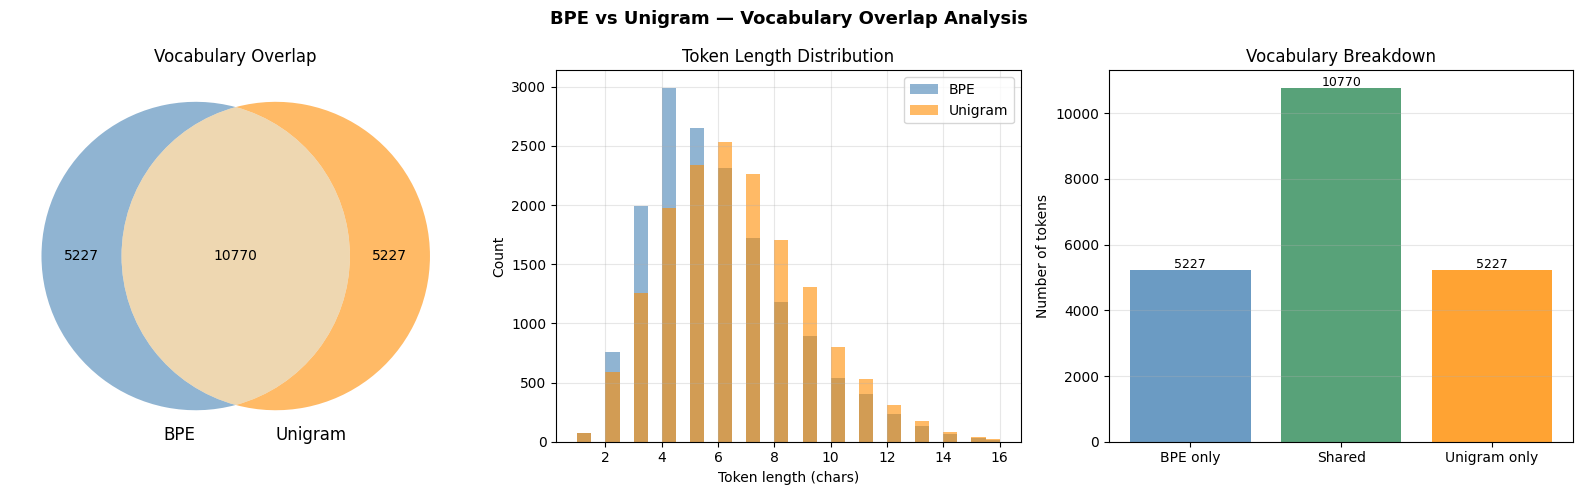

In [9]:
# Evaluating overlap in tokenizations of BPE vs Unigram

import sentencepiece as spm
import matplotlib.pyplot as plt
import matplotlib_venn as venn

bpe = spm.SentencePieceProcessor(model_file='marathi_bpe.model')
uni = spm.SentencePieceProcessor(model_file='marathi_unigram.model')

bpe_vocab = set()
for i in range(bpe.vocab_size()):
    piece = bpe.id_to_piece(i)
    if not piece.startswith('<'):
        bpe_vocab.add(piece)

uni_vocab = set()
for i in range(uni.vocab_size()):
    piece = uni.id_to_piece(i)
    if not piece.startswith('<'):
        uni_vocab.add(piece)

# Counts
shared      = bpe_vocab & uni_vocab
bpe_only    = bpe_vocab - uni_vocab
uni_only    = uni_vocab - bpe_vocab

print(f"BPE vocab size       : {len(bpe_vocab):,}")
print(f"Unigram vocab size   : {len(uni_vocab):,}")
print(f"Shared tokens        : {len(shared):,}")
print(f"BPE only             : {len(bpe_only):,}")
print(f"Unigram only         : {len(uni_only):,}")
print(f"Overlap (Jaccard)    : {len(shared) / len(bpe_vocab | uni_vocab):.4f}")
print(f"Overlap % of BPE     : {len(shared) / len(bpe_vocab) * 100:.2f}%")
print(f"Overlap % of Unigram : {len(shared) / len(uni_vocab) * 100:.2f}%")

# Token lengths
bpe_lengths = [len(p) for p in bpe_vocab]
uni_lengths = [len(p) for p in uni_vocab]

print(f"\nAverage token length (BPE)    : {sum(bpe_lengths)/len(bpe_lengths):.2f} chars")
print(f"Average token length (Unigram): {sum(uni_lengths)/len(uni_lengths):.2f} chars")

# Some shared and unique tokens
import random
random.seed(42)

print(f"\nSample SHARED tokens (appear in both):")
print(random.sample(sorted(shared), min(10, len(shared))))

print(f"\nSample BPE-only tokens:")
print(random.sample(sorted(bpe_only), min(10, len(bpe_only))))

print(f"\nSample Unigram-only tokens:")
print(random.sample(sorted(uni_only), min(10, len(uni_only))))

# Plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Venn diagram
from matplotlib_venn import venn2
ax = axes[0]
plt.sca(ax)
venn2(
    subsets=(len(bpe_only), len(uni_only), len(shared)),
    set_labels=('BPE', 'Unigram'),
    set_colors=('steelblue', 'darkorange'),
    alpha=0.6
)
ax.set_title('Vocabulary Overlap')

# Token lengths
ax = axes[1]
ax.hist(bpe_lengths, bins=30, alpha=0.6, color='steelblue', label='BPE')
ax.hist(uni_lengths, bins=30, alpha=0.6, color='darkorange', label='Unigram')
ax.set_xlabel('Token length (chars)')
ax.set_ylabel('Count')
ax.set_title('Token Length Distribution')
ax.legend()
ax.grid(alpha=0.3)

# 3. Bar plots of Shared vs. Unique tokens in BPE and Unigram
ax = axes[2]
categories = ['BPE only', 'Shared', 'Unigram only']
counts     = [len(bpe_only), len(shared), len(uni_only)]
colors     = ['steelblue', 'seagreen', 'darkorange']
ax.bar(categories, counts, color=colors, alpha=0.8)
ax.set_ylabel('Number of tokens')
ax.set_title('Vocabulary Breakdown')
ax.grid(axis='y', alpha=0.3)
for i, (cat, cnt) in enumerate(zip(categories, counts)):
    ax.text(i, cnt + 50, str(cnt), ha='center', fontsize=9)

plt.suptitle('BPE vs Unigram — Vocabulary Overlap Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vocab_overlap.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:

#Testing BPE and Unigram tokenizers on Kaggle Marathi News Dataset
#Dataset:kagglehub.dataset_download("disisbig/marathi-news-dataset")

import kagglehub
import os
import pandas as pd
import sentencepiece as spm
from IPython.display import display

path = kagglehub.dataset_download("disisbig/marathi-news-dataset")

print("Path to dataset files:", path)

all_files = []

for root, dirs, files in os.walk(path):
    for file in files:
        file_path = os.path.join(root, file)
        all_files.append(file_path)

print("Files found:")
for file_path in all_files:
    print(file_path)

raw_texts = []

for file_path in all_files:
    file_lower = file_path.lower()

    if file_lower.endswith(".csv"):
        df = pd.read_csv(file_path)

        print("\nLoaded CSV:", file_path)
        print("Columns:", df.columns.tolist())
        display(df.head())

        # Try common text/headline/content column names first
        possible_text_columns = [
            "text",
            "headline",
            "title",
            "content",
            "news",
            "article",
            "body",
            "description"
        ]

        text_column = None

        for col in possible_text_columns:
            if col in df.columns:
                text_column = col
                break

        # Fallback: use the first object/string column
        if text_column is None:
            object_columns = df.select_dtypes(include=["object"]).columns.tolist()

            if len(object_columns) == 0:
                print("No text-like columns found in:", file_path)
                continue

            text_column = object_columns[0]

        print("Using text column:", text_column)

        raw_texts.extend(
            df[text_column]
            .dropna()
            .astype(str)
            .tolist()
        )

    elif file_lower.endswith(".txt"):
        print("\nLoaded TXT:", file_path)

        with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
            lines = f.readlines()

        raw_texts.extend([
            line.strip()
            for line in lines
            if line.strip()
        ])

print("\nTotal raw text entries collected:", len(raw_texts))

if len(raw_texts) == 0:
    raise ValueError(
        "No text entries were loaded. Check the printed file names and columns."
    )

# Text normalization of the test set

normalized_news_texts = []
skipped_texts = 0

for text in raw_texts:
    normalized_text = normalize_marathi(text.strip())

    if len(normalized_text.split()) < 3:
        skipped_texts += 1
        continue

    normalized_news_texts.append(normalized_text)

normalized_news_texts = list(dict.fromkeys(normalized_news_texts))

print("Total normalized news texts kept:", len(normalized_news_texts))
print("Total skipped texts:", skipped_texts)

if len(normalized_news_texts) == 0:
    raise ValueError(
        "No usable text after normalization."
    )

print("\nFirst normalized text:")
print(normalized_news_texts[0])

bpe_model_path = "marathi_bpe.model"
unigram_model_path = "marathi_unigram.model"

bpe_tokenizer = spm.SentencePieceProcessor(model_file=bpe_model_path)
unigram_tokenizer = spm.SentencePieceProcessor(model_file=unigram_model_path)

bpe_evaluator = TokenizerEvaluator(bpe_model_path)
unigram_evaluator = TokenizerEvaluator(unigram_model_path)

news_level_results = []

for i, text in enumerate(normalized_news_texts, start=1):
    text = text.strip()

    # Avoid ZeroDivisionError
    if len(text.split()) == 0:
        continue

    bpe_metrics = bpe_evaluator.evaluate(text)
    unigram_metrics = unigram_evaluator.evaluate(text)

    bpe_tokens = bpe_tokenizer.encode_as_pieces(text)
    unigram_tokens = unigram_tokenizer.encode_as_pieces(text)

    row = {
        "Text No.": i,
        "Normalized News Text": text,

        "BPE Tokens": bpe_tokens,
        "BPE Token Count": len(bpe_tokens),

        "Unigram Tokens": unigram_tokens,
        "Unigram Token Count": len(unigram_tokens),

        "Token Count Difference": len(bpe_tokens) - len(unigram_tokens)
    }

    for metric_name, metric_value in bpe_metrics.items():
        row[f"BPE {metric_name}"] = metric_value

    for metric_name, metric_value in unigram_metrics.items():
        row[f"Unigram {metric_name}"] = metric_value

    news_level_results.append(row)

news_level_df = pd.DataFrame(news_level_results)

print("Total news texts evaluated:", len(news_level_df))

if len(news_level_df) == 0:
    raise ValueError("No news texts were evaluated.")

# Evaluating 10 random tokenization examples (using random_state)

sample_10_df = news_level_df.sample(
    n=min(10, len(news_level_df)),
    random_state=42
).reset_index(drop=True)

display_columns = [
    "Text No.",
    "Normalized News Text",
    "BPE Tokens",
    "BPE Token Count",
    "Unigram Tokens",
    "Unigram Token Count",
    "Token Count Difference"
]

print("\n10 random Marathi news examples and their tokenization:")
display(sample_10_df[display_columns])

# Stats

bpe_metric_columns = [
    col for col in news_level_df.columns
    if col.startswith("BPE ") and col != "BPE Tokens"
]

unigram_metric_columns = [
    col for col in news_level_df.columns
    if col.startswith("Unigram ") and col != "Unigram Tokens"
]

bpe_summary = news_level_df[bpe_metric_columns].mean(numeric_only=True)
unigram_summary = news_level_df[unigram_metric_columns].mean(numeric_only=True)

bpe_summary.index = [col.replace("BPE ", "") for col in bpe_summary.index]
unigram_summary.index = [col.replace("Unigram ", "") for col in unigram_summary.index]

evaluator_summary_df = pd.DataFrame({
    "BPE": bpe_summary,
    "Unigram": unigram_summary
})

print("\nSummary statistics from TokenizerEvaluator.evaluate():")
display(evaluator_summary_df)

# Counts

token_count_summary_df = pd.DataFrame({
    "Model": ["BPE", "Unigram"],
    "Average Tokens per Text": [
        news_level_df["BPE Token Count"].mean(),
        news_level_df["Unigram Token Count"].mean()
    ],
    "Minimum Tokens in a Text": [
        news_level_df["BPE Token Count"].min(),
        news_level_df["Unigram Token Count"].min()
    ],
    "Maximum Tokens in a Text": [
        news_level_df["BPE Token Count"].max(),
        news_level_df["Unigram Token Count"].max()
    ],
    "Total Tokens on News Test Set": [
        news_level_df["BPE Token Count"].sum(),
        news_level_df["Unigram Token Count"].sum()
    ]
})

print("\nToken count summary over the full Marathi news test set:")
display(token_count_summary_df)

#saving output

news_level_df.to_csv(
    "kaggle_marathi_news_full_test_bpe_vs_unigram.csv",
    index=False,
    encoding="utf-8-sig"
)

sample_10_df[display_columns].to_csv(
    "kaggle_marathi_news_sample_10_tokenization_examples.csv",
    index=False,
    encoding="utf-8-sig"
)

evaluator_summary_df.to_csv(
    "kaggle_marathi_news_test_evaluator_summary.csv",
    encoding="utf-8-sig"
)

token_count_summary_df.to_csv(
    "kaggle_marathi_news_test_token_count_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved files:")
print("kaggle_marathi_news_full_test_bpe_vs_unigram.csv")
print("kaggle_marathi_news_sample_10_tokenization_examples.csv")
print("kaggle_marathi_news_test_evaluator_summary.csv")
print("kaggle_marathi_news_test_token_count_summary.csv")

100%|██████████| 496k/496k [00:00<00:00, 65.4MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/disisbig/marathi-news-dataset/versions/1
Files found:
/root/.cache/kagglehub/datasets/disisbig/marathi-news-dataset/versions/1/valid.csv
/root/.cache/kagglehub/datasets/disisbig/marathi-news-dataset/versions/1/train.csv

Loaded CSV: /root/.cache/kagglehub/datasets/disisbig/marathi-news-dataset/versions/1/valid.csv
Columns: ['headline', 'label']


,headline,label
0,पहाटे 3:30 वाजता बीग बींनी गायल 'हे' रॅप साँग,entertainment
1,राष्ट्रपती आणि पंतप्रधानांनी वाहिली श्रीदेवींन...,entertainment
2,सायरा बानोंना जागेसाठी धमकावणाऱ्या बिल्डराविरो...,entertainment
3,"मुंबईत पहिल्यांदाच पन्नाशी पार, राज्यात सरासरी...",state
4,अण्णांची मनधरणी करण्यासाठी गिरीश महाजन राळेगणस...,state


Using text column: headline

Loaded CSV: /root/.cache/kagglehub/datasets/disisbig/marathi-news-dataset/versions/1/train.csv
Columns: ['headline', 'label']


,headline,label
0,सचिन तेंडुलकरने बाळासाहेबांच्या आठवणींना दिला ...,state
1,"बहुजन वंचित आघाडीची पहिली यादी जाहीर, प्रकाश आ...",state
2,"गृहमंत्रिपद हे पार्ट टाइम नाही, राजीनामा द्या,...",state
3,पुण्यात आघाडीचा पोपट पुन्हा जिवंत !,state
4,शरद पवार यांनी मिलिंद नार्वेकर यांच्या कानात क...,state


...


Summary statistics from TokenizerEvaluator.evaluate():


,BPE,Unigram
Token Count,12.971315,12.656372
Fertility Score,1.927813,1.882016
Characters per Token,3.529510,3.632716
Word Fragmentation Rate (%),56.928530,53.770063



Token count summary over the full Marathi news test set:


,Model,Average Tokens per Text,Minimum Tokens in a Text,Maximum Tokens in a Text,Total Tokens on News Test Set
0,BPE,12.971315,3,38,153295
1,Unigram,12.656372,3,38,149573



Saved files:
kaggle_marathi_news_full_test_bpe_vs_unigram.csv
kaggle_marathi_news_sample_10_tokenization_examples.csv
kaggle_marathi_news_test_evaluator_summary.csv
kaggle_marathi_news_test_token_count_summary.csv


In [11]:
#descriptive stats of unique and shared tokens in bpe and unigram

import pandas as pd
from IPython.display import display

bpe_all_tokens = []
unigram_all_tokens = []

for tokens in news_level_df["BPE Tokens"]:
    bpe_all_tokens.extend(tokens)

for tokens in news_level_df["Unigram Tokens"]:
    unigram_all_tokens.extend(tokens)

bpe_token_set = set(bpe_all_tokens)
unigram_token_set = set(unigram_all_tokens)

overlapping_tokens = bpe_token_set.intersection(unigram_token_set)

bpe_unique_tokens = bpe_token_set.difference(unigram_token_set)
unigram_unique_tokens = unigram_token_set.difference(bpe_token_set)

token_overlap_summary_df = pd.DataFrame({
    "Category": [
        "Total unique BPE tokens in test set",
        "Total unique Unigram tokens in test set",
        "Overlapping tokens",
        "Tokens unique to BPE",
        "Tokens unique to Unigram"
    ],
    "Count": [
        len(bpe_token_set),
        len(unigram_token_set),
        len(overlapping_tokens),
        len(bpe_unique_tokens),
        len(unigram_unique_tokens)
    ]
})

display(token_overlap_summary_df)

percentage_summary_df = pd.DataFrame({
    "Metric": [
        "Percentage of BPE test tokens also found in Unigram",
        "Percentage of Unigram test tokens also found in BPE",
        "Percentage of BPE test tokens unique to BPE",
        "Percentage of Unigram test tokens unique to Unigram"
    ],
    "Percentage": [
        (len(overlapping_tokens) / len(bpe_token_set)) * 100 if len(bpe_token_set) > 0 else 0,
        (len(overlapping_tokens) / len(unigram_token_set)) * 100 if len(unigram_token_set) > 0 else 0,
        (len(bpe_unique_tokens) / len(bpe_token_set)) * 100 if len(bpe_token_set) > 0 else 0,
        (len(unigram_unique_tokens) / len(unigram_token_set)) * 100 if len(unigram_token_set) > 0 else 0
    ]
})

display(percentage_summary_df)

#examples

num_examples = 50

token_examples_df = pd.DataFrame({
    "Overlapping Tokens": sorted(list(overlapping_tokens))[:num_examples],
    "BPE-Only Tokens": sorted(list(bpe_unique_tokens))[:num_examples],
    "Unigram-Only Tokens": sorted(list(unigram_unique_tokens))[:num_examples]
})

display(token_examples_df)

# saving output

token_overlap_summary_df.to_csv(
    "test_set_token_overlap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

percentage_summary_df.to_csv(
    "test_set_token_overlap_percentages.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame({"Overlapping Tokens": sorted(list(overlapping_tokens))}).to_csv(
    "test_set_overlapping_tokens.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame({"BPE Only Tokens": sorted(list(bpe_unique_tokens))}).to_csv(
    "test_set_bpe_only_tokens.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame({"Unigram Only Tokens": sorted(list(unigram_unique_tokens))}).to_csv(
    "test_set_unigram_only_tokens.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Saved token overlap outputs:")
print("test_set_token_overlap_summary.csv")
print("test_set_token_overlap_percentages.csv")
print("test_set_overlapping_tokens.csv")
print("test_set_bpe_only_tokens.csv")
print("test_set_unigram_only_tokens.csv")

,Category,Count
0,Total unique BPE tokens in test set,9789
1,Total unique Unigram tokens in test set,9308
2,Overlapping tokens,6984
3,Tokens unique to BPE,2805
4,Tokens unique to Unigram,2324


,Metric,Percentage
0,Percentage of BPE test tokens also found in Un...,71.345388
1,Percentage of Unigram test tokens also found i...,75.032230
2,Percentage of BPE test tokens unique to BPE,28.654612
3,Percentage of Unigram test tokens unique to Un...,24.967770


,Overlapping Tokens,BPE-Only Tokens,Unigram-Only Tokens
0,!,.-,11
1,!!,..,12
2,!!!,...,18
3,",",....,23
4,-,.2,30
5,-1,201,ंगर
6,-19,ँक,ंगो
7,-2,ँच,ंग्
8,-20,ंकर,ंग्ल
9,-3,ंकू,ंचं


Saved token overlap outputs:
test_set_token_overlap_summary.csv
test_set_token_overlap_percentages.csv
test_set_overlapping_tokens.csv
test_set_bpe_only_tokens.csv
test_set_unigram_only_tokens.csv


BPE vs Unigram — Test Set Token Overlap
--------------------------------------------------
BPE test token types       : 9,789
Unigram test token types   : 9,308
Shared test token types    : 6,984
BPE-only test token types  : 2,805
Unigram-only token types   : 2,324
Overlap Jaccard score      : 0.5766
Overlap % of BPE           : 71.35%
Overlap % of Unigram       : 75.03%

Token Length Statistics on Test Set
--------------------------------------------------
Average token length BPE       : 5.26 chars
Shortest BPE token length      : 1 chars
Longest BPE token length       : 16 chars
Average token length Unigram   : 5.72 chars
Shortest Unigram token length  : 1 chars
Longest Unigram token length   : 16 chars

Sample SHARED test tokens:
['▁मावळ', 'ल', 'क्ल', '▁वीर', '▁कंद', '▁आशिया', '▁असल्यास', 'सार', '▁विभागाच्या', 'या']

Sample BPE-only test tokens:
['▁हल्ल', '▁बहि', 'दम', '▁यान', '▁क्ष', 'क्टोबर', 'कुश', 'धित', 'सीसी', 'ांगी']

Sample Unigram-only test tokens:
['▁शतकात', 'टर्न', '▁हलव

,Category,Count
0,BPE test token types,9789
1,Unigram test token types,9308
2,Shared test token types,6984
3,BPE-only test token types,2805
4,Unigram-only test token types,2324


,Metric,Value
0,Jaccard overlap,0.576571
1,Overlap % of BPE,71.345388
2,Overlap % of Unigram,75.032230
3,Average BPE token length,5.259884
4,Average Unigram token length,5.722174


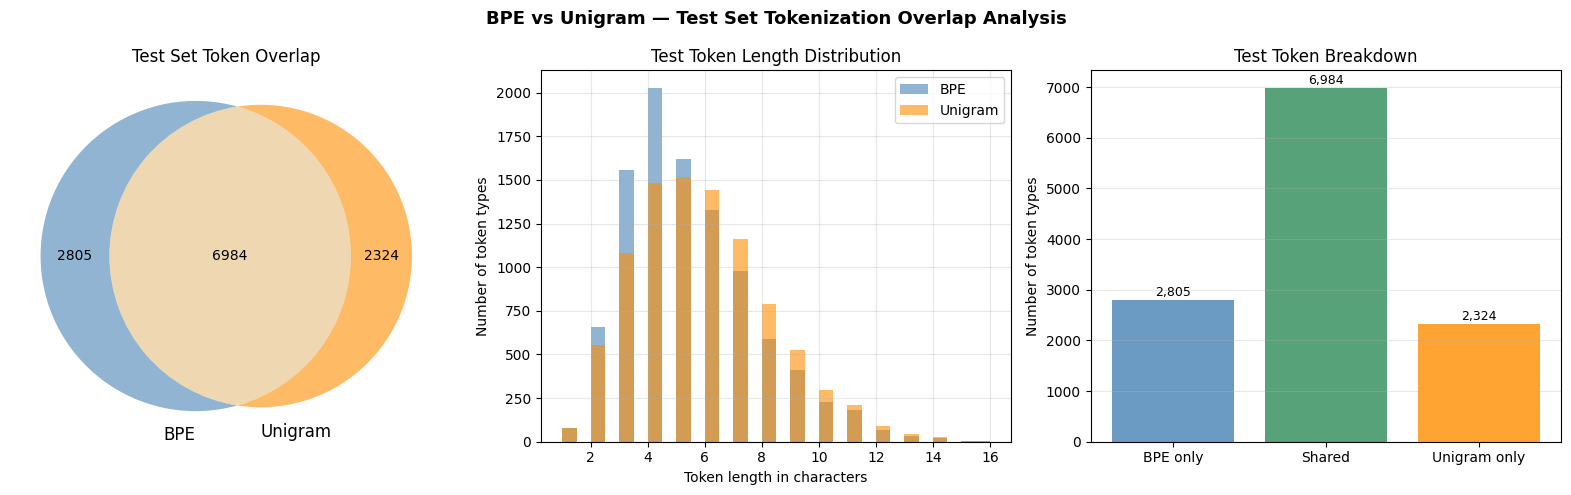


Saved files:
test_set_token_overlap.png
test_set_token_overlap_summary.csv
test_set_token_overlap_metrics.csv
test_set_shared_tokens.csv
test_set_bpe_only_tokens.csv
test_set_unigram_only_tokens.csv


In [12]:
# analysis of unique and shared tokens

import matplotlib.pyplot as plt
from matplotlib_venn import venn2
import random
import pandas as pd

bpe_test_tokens = set()
uni_test_tokens = set()

for tokens in news_level_df["BPE Tokens"]:
    bpe_test_tokens.update(tokens)

for tokens in news_level_df["Unigram Tokens"]:
    uni_test_tokens.update(tokens)

bpe_test_tokens = {
    token for token in bpe_test_tokens
    if not token.startswith("<")
}

uni_test_tokens = {
    token for token in uni_test_tokens
    if not token.startswith("<")
}

shared = bpe_test_tokens & uni_test_tokens
bpe_only = bpe_test_tokens - uni_test_tokens
uni_only = uni_test_tokens - bpe_test_tokens

union = bpe_test_tokens | uni_test_tokens

print("BPE vs Unigram — Test Set Token Overlap")
print("-" * 50)

print(f"BPE test token types       : {len(bpe_test_tokens):,}")
print(f"Unigram test token types   : {len(uni_test_tokens):,}")
print(f"Shared test token types    : {len(shared):,}")
print(f"BPE-only test token types  : {len(bpe_only):,}")
print(f"Unigram-only token types   : {len(uni_only):,}")

if len(union) > 0:
    print(f"Overlap Jaccard score      : {len(shared) / len(union):.4f}")
else:
    print("Overlap Jaccard score      : 0.0000")

if len(bpe_test_tokens) > 0:
    print(f"Overlap % of BPE           : {len(shared) / len(bpe_test_tokens) * 100:.2f}%")
else:
    print("Overlap % of BPE           : 0.00%")

if len(uni_test_tokens) > 0:
    print(f"Overlap % of Unigram       : {len(shared) / len(uni_test_tokens) * 100:.2f}%")
else:
    print("Overlap % of Unigram       : 0.00%")

# token length stats

bpe_lengths = [len(token) for token in bpe_test_tokens]
uni_lengths = [len(token) for token in uni_test_tokens]

print("\nToken Length Statistics on Test Set")
print("-" * 50)

if len(bpe_lengths) > 0:
    print(f"Average token length BPE       : {sum(bpe_lengths) / len(bpe_lengths):.2f} chars")
    print(f"Shortest BPE token length      : {min(bpe_lengths)} chars")
    print(f"Longest BPE token length       : {max(bpe_lengths)} chars")

if len(uni_lengths) > 0:
    print(f"Average token length Unigram   : {sum(uni_lengths) / len(uni_lengths):.2f} chars")
    print(f"Shortest Unigram token length  : {min(uni_lengths)} chars")
    print(f"Longest Unigram token length   : {max(uni_lengths)} chars")

# examples of unique and shared tokens
random.seed(42)

print("\nSample SHARED test tokens:")
print(random.sample(sorted(shared), min(10, len(shared))))

print("\nSample BPE-only test tokens:")
print(random.sample(sorted(bpe_only), min(10, len(bpe_only))))

print("\nSample Unigram-only test tokens:")
print(random.sample(sorted(uni_only), min(10, len(uni_only))))

token_overlap_summary_df = pd.DataFrame({
    "Category": [
        "BPE test token types",
        "Unigram test token types",
        "Shared test token types",
        "BPE-only test token types",
        "Unigram-only test token types"
    ],
    "Count": [
        len(bpe_test_tokens),
        len(uni_test_tokens),
        len(shared),
        len(bpe_only),
        len(uni_only)
    ]
})

display(token_overlap_summary_df)

token_overlap_metrics_df = pd.DataFrame({
    "Metric": [
        "Jaccard overlap",
        "Overlap % of BPE",
        "Overlap % of Unigram",
        "Average BPE token length",
        "Average Unigram token length"
    ],
    "Value": [
        len(shared) / len(union) if len(union) > 0 else 0,
        len(shared) / len(bpe_test_tokens) * 100 if len(bpe_test_tokens) > 0 else 0,
        len(shared) / len(uni_test_tokens) * 100 if len(uni_test_tokens) > 0 else 0,
        sum(bpe_lengths) / len(bpe_lengths) if len(bpe_lengths) > 0 else 0,
        sum(uni_lengths) / len(uni_lengths) if len(uni_lengths) > 0 else 0
    ]
})

display(token_overlap_metrics_df)

# plots

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Venn diagram
ax = axes[0]
plt.sca(ax)

venn2(
    subsets=(len(bpe_only), len(uni_only), len(shared)),
    set_labels=("BPE", "Unigram"),
    set_colors=("steelblue", "darkorange"),
    alpha=0.6
)

ax.set_title("Test Set Token Overlap")

# Token length histogram
ax = axes[1]

ax.hist(
    bpe_lengths,
    bins=30,
    alpha=0.6,
    color="steelblue",
    label="BPE"
)

ax.hist(
    uni_lengths,
    bins=30,
    alpha=0.6,
    color="darkorange",
    label="Unigram"
)

ax.set_xlabel("Token length in characters")
ax.set_ylabel("Number of token types")
ax.set_title("Test Token Length Distribution")
ax.legend()
ax.grid(alpha=0.3)

# Bar plot of shared vs unique tokens
ax = axes[2]

categories = ["BPE only", "Shared", "Unigram only"]
counts = [len(bpe_only), len(shared), len(uni_only)]
colors = ["steelblue", "seagreen", "darkorange"]

ax.bar(
    categories,
    counts,
    color=colors,
    alpha=0.8
)

ax.set_ylabel("Number of token types")
ax.set_title("Test Token Breakdown")
ax.grid(axis="y", alpha=0.3)

for i, count in enumerate(counts):
    ax.text(
        i,
        count + max(counts) * 0.01,
        f"{count:,}",
        ha="center",
        fontsize=9
    )

plt.suptitle(
    "BPE vs Unigram — Test Set Tokenization Overlap Analysis",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.savefig(
    "test_set_token_overlap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

# saving

token_overlap_summary_df.to_csv(
    "test_set_token_overlap_summary.csv",
    index=False,
    encoding="utf-8-sig"
)

token_overlap_metrics_df.to_csv(
    "test_set_token_overlap_metrics.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame({"Shared Test Tokens": sorted(shared)}).to_csv(
    "test_set_shared_tokens.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame({"BPE Only Test Tokens": sorted(bpe_only)}).to_csv(
    "test_set_bpe_only_tokens.csv",
    index=False,
    encoding="utf-8-sig"
)

pd.DataFrame({"Unigram Only Test Tokens": sorted(uni_only)}).to_csv(
    "test_set_unigram_only_tokens.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved files:")
print("test_set_token_overlap.png")
print("test_set_token_overlap_summary.csv")
print("test_set_token_overlap_metrics.csv")
print("test_set_shared_tokens.csv")
print("test_set_bpe_only_tokens.csv")
print("test_set_unigram_only_tokens.csv")

In [13]:
# bpe vs unigram tokenization for the same sentences

from IPython.display import display
import pandas as pd

# using random_state
same_10_examples = news_level_df.sample(
    n=min(10, len(news_level_df)),
    random_state=130
).reset_index(drop=True)

# Display sentence/headline + both tokenizations
same_10_display = same_10_examples[
    [
        "Text No.",
        "Normalized News Text",
        "BPE Tokens",
        "BPE Token Count",
        "Unigram Tokens",
        "Unigram Token Count",
        "Token Count Difference"
    ]
]

display(same_10_display)

,Text No.,Normalized News Text,BPE Tokens,BPE Token Count,Unigram Tokens,Unigram Token Count,Token Count Difference
0,11229,अतुल तापकीर आत्महत्येप्रकरणी पत्नी प्रियंकासह ...,"[▁अतुल, ▁ताप, कीर, ▁आत्मह, त्ये, प्र, करणी, ▁प...",15,"[▁अतुल, ▁ताप, की, र, ▁आत्महत्ये, प्र, कर, णी, ...",16,-1
1,2231,भंडार्यात लाखांचा दारूसाठा जप्त,"[▁भंड, ार, ्यात, ▁लाख, ांचा, ▁दारू, सा, ठा, ▁ज...",10,"[▁भंडार, ्यात, ▁लाख, ांचा, ▁दारू, साठ, ा, ▁जप्त]",8,2
2,7220,प्रकाश आंबेडकरांमुळेच महाराष्ट्र पेटला- संभाजी...,"[▁प्रकाश, ▁आंबेडकर, ांमुळे, च, ▁महाराष्ट्र, ▁प...",14,"[▁प्रकाश, ▁आंबेडकर, ांमुळे, च, ▁महाराष्ट्र, ▁प...",14,0
3,9878,"माजी नगरसेवक पुत्राची युवकाला जबर मारहाण, एक ड...","[▁माजी, ▁नगरसेवक, ▁पुत्र, ाची, ▁युव, काला, ▁जब...",16,"[▁माजी, ▁नगरसेवक, ▁पुत्र, ाची, ▁युवक, ाला, ▁जब...",14,2
4,2199,पांड्या कॅच बघून जॉन्टी ऱ्होड्सची आठवण येईल,"[▁पांड, ्या, ▁कॅ, च, ▁बघ, ून, ▁जॉ, न्, टी, ▁ऱ्...",15,"[▁पांड, ्या, ▁कॅ, च, ▁बघून, ▁जॉन, ्टी, ▁ऱ्होड,...",12,3
5,1147,मुख्यमंत्र्यांच्या नागपुरात सिमेंट क्राँकीट रस...,"[▁मुख्यमंत्र, ्यांच्या, ▁नाग, पुरात, ▁सिमेंट, ...",17,"[▁मुख्यमंत्र्यां, च्या, ▁नागपुरात, ▁सिमेंट, ▁क...",16,1
6,6891,भाजपला धक्का प्रशांत हिरे आणि अपूर्व हिरेंची र...,"[▁भाजप, ला, ▁धक्का, ▁प्रशांत, ▁हि, रे, ▁आणि, ▁...",18,"[▁भाजप, ला, ▁धक्का, ▁प्रशांत, ▁हिर, े, ▁आणि, ▁...",18,0
7,6223,पंकजा मुंडेंना मंत्रिपदावर राहण्याचा अधिकार ना...,"[▁पंक, जा, ▁मुंडे, ंना, ▁मंत्र, ि, पदावर, ▁राह...",15,"[▁पंकज, ा, ▁मुंडे, ंना, ▁मंत्र, ि, पदावर, ▁राह...",16,-1
8,10797,"रात्रीस खेळ चाले-2मध्ये शेवंताची एंट्री, असं आ...","[▁रात्री, स, ▁खेळ, ▁चा, ले, -2, मध्ये, ▁शेव, ं...",22,"[▁रात्री, स, ▁खेळ, ▁चाल, े, -2, मध्ये, ▁शेव, ं...",20,2
9,8509,"तूर विकली नाही, ना मोसंबी म्हणून फेकून दिली","[▁त, ूर, ▁विक, ली, ▁नाही, ,, ▁ना, ▁मो, संब, ी,...",14,"[▁तू, र, ▁विकली, ▁नाही, ,, ▁ना, ▁मो, स, ंबी, ▁...",13,1


Training Morfessor model...


100% (744835 of 744835) |################| Elapsed Time: 0:06:01 Time:  0:06:01
100% (744835 of 744835) |################| Elapsed Time: 0:06:01 Time:  0:06:01
100% (744835 of 744835) |################| Elapsed Time: 0:06:02 Time:  0:06:02


Morfessor training complete.

Tokenising test set with Morfessor...
Done.

Intrinsic Metrics


,Fertility Score,Chars per Token,Word Fragmentation Rate (%)
Tokenizer,,,
BPE,1.8904,3.4239,89.04
Unigram,1.8445,3.5091,84.45
Morfessor,1.3041,4.9682,30.41



Vocabulary Overlap (test-set token types)


,Region,Count
0,All three shared,5264
1,BPE & Unigram only,1091
2,BPE & Morfessor only,495
3,Unigram & Morfessor only,1322
4,BPE only,1945
5,Unigram only,763
6,Morfessor only,11872



Per-tokenizer vocabulary breakdown


,Tokenizer,Unique types,Shared with >=1 other (%),Exclusive to this tokenizer (%)
0,BPE,8795,77.89,22.11
1,Unigram,8440,90.96,9.04
2,Morfessor,18953,37.36,62.64



Sample BPE-only tokens:       ['्यांकडे', 'डित', 'लंग', 'कायद', 'फर्', 'ाबत', 'शिष', 'डीचा', 'डिझायन', 'प्रच']
Sample Unigram-only tokens:   ['बंदर', 'झोपडी', 'विद्यार्थ्या', 'वाढवत', 'दहशतवाद्यां', 'ेक्स', 'तुरूंग', 'वंत', 'चलित', 'ाइन']
Sample Morfessor-only tokens: ['नगरपरिषदा', 'बिईंग', 'अडसूळ', 'ियों', 'भुजबळ,', 'वश', 'दिघ', 'हेट', 'बारामतीत', 'गाण्याची']
Sample all-three shared:      ['आर्थिक', 'उतरले', 'मकरंद', 'थे', 'आण', 'धावा', 'स्मिथ', 'लेले', 'काटे', 'बिल']


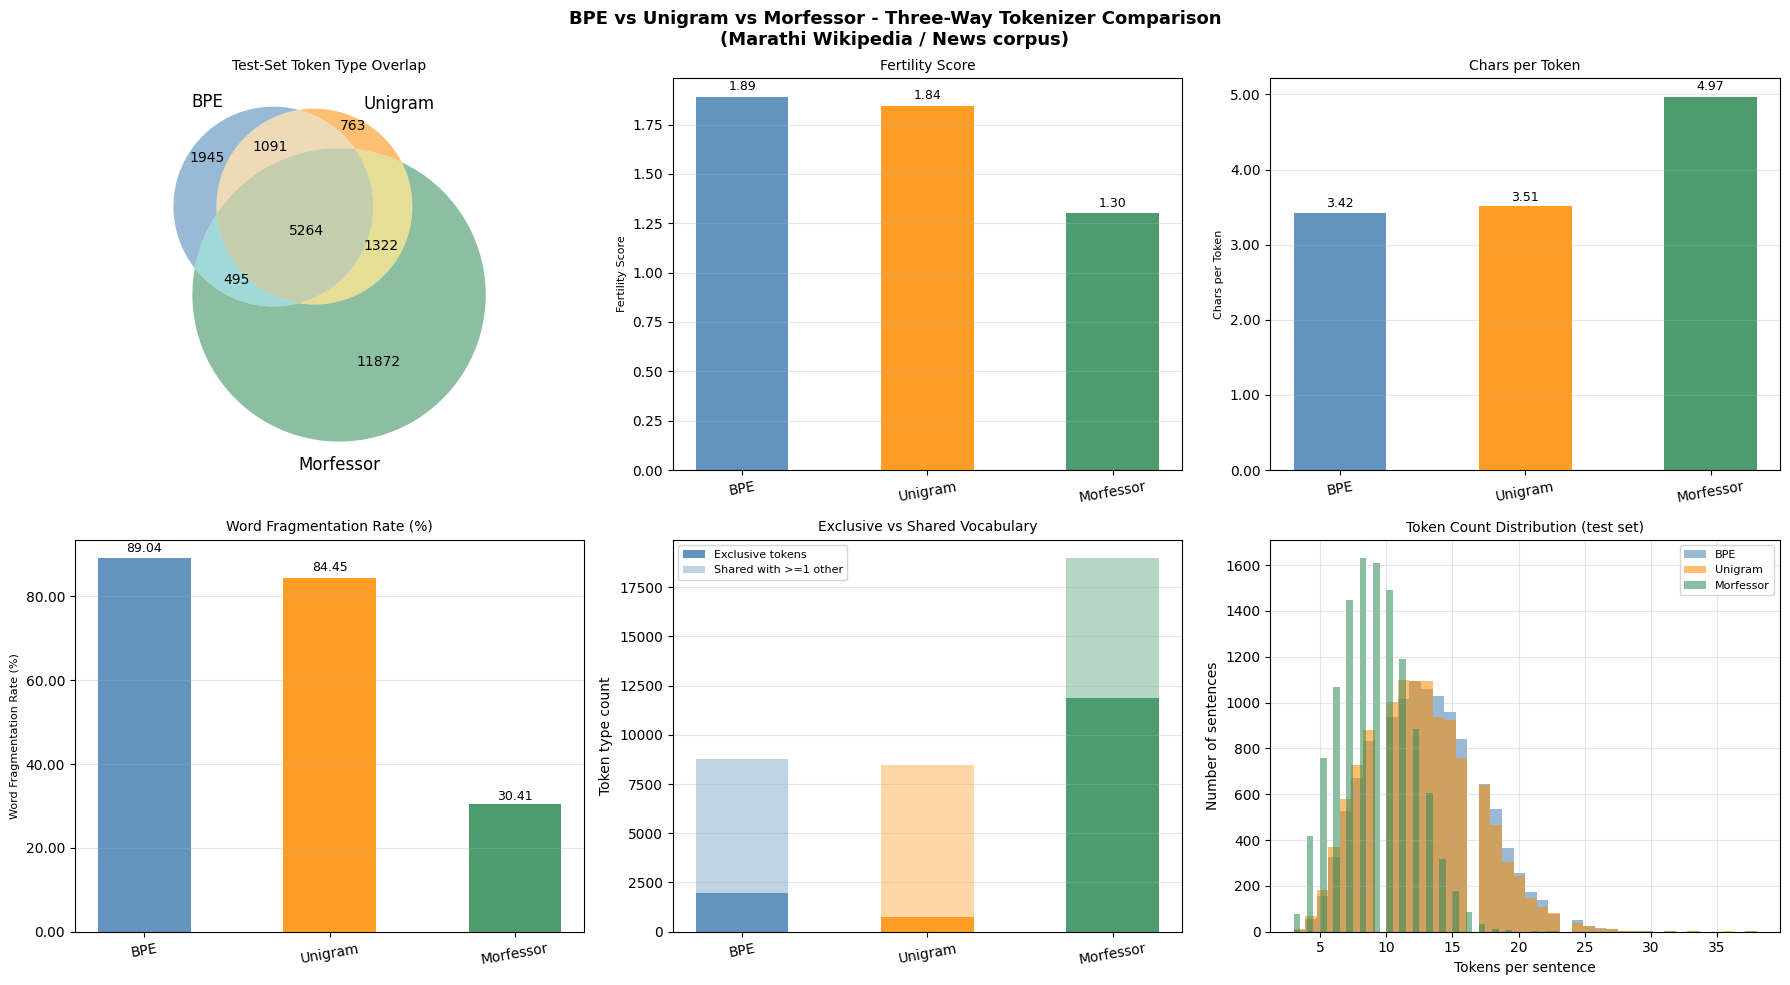

Plot saved: three_way_tokenizer_comparison.png

Tokenization Examples (10 random test sentences)


,Text No.,Normalized News Text,BPE Tokens,BPE Token Count,Unigram Tokens,Unigram Token Count,Morfessor Tokens,Morfessor Token Count
0,11229,अतुल तापकीर आत्महत्येप्रकरणी पत्नी प्रियंकासह चौघांना अटक,▁अतुल | ▁ताप | कीर | ▁आत्मह | त्ये | प्र | करणी | ▁पत्नी | ▁प्रिय | ंक | ासह | ▁चौ | घ | ांना | ▁अटक,15,▁अतुल | ▁ताप | की | र | ▁आत्महत्ये | प्र | कर | णी | ▁पत्नी | ▁प्रिय | ंक | ासह | ▁चौ | घ | ांना | ▁अटक,16,अतुल | तापकीर | आत्महत्ये | प्रकरणी | पत्नी | प्रियंका | सह | चौघांना | अटक,9
1,2231,भंडार्यात लाखांचा दारूसाठा जप्त,▁भंड | ार | ्यात | ▁लाख | ांचा | ▁दारू | सा | ठा | ▁ज | प्त,10,▁भंडार | ्यात | ▁लाख | ांचा | ▁दारू | साठ | ा | ▁जप्त,8,भंडार | ्यात | लाखांचा | दारू | साठा | जप्त,6
2,7220,प्रकाश आंबेडकरांमुळेच महाराष्ट्र पेटला- संभाजी भिडे यांचा पलटवार,▁प्रकाश | ▁आंबेडकर | ांमुळे | च | ▁महाराष्ट्र | ▁पेट | ला | - | ▁संभाजी | ▁भिडे | ▁यांचा | ▁प | लट | वार,14,▁प्रकाश | ▁आंबेडकर | ांमुळे | च | ▁महाराष्ट्र | ▁पेट | ला | - | ▁संभाजी | ▁भिडे | ▁यांचा | ▁पल | ट | वार,14,प्रकाश | आंबेडकर | ांमुळे | च | महाराष्ट्र | पेटला | - | संभाजी | भिडे | यांचा | पलटवार,11
3,9878,"माजी नगरसेवक पुत्राची युवकाला जबर मारहाण, एक डोळा केला निकामी","▁माजी | ▁नगरसेवक | ▁पुत्र | ाची | ▁युव | काला | ▁जबर | ▁मार | हाण | , | ▁एक | ▁डो | ळा | ▁केला | ▁निक | ामी",16,"▁माजी | ▁नगरसेवक | ▁पुत्र | ाची | ▁युवक | ाला | ▁जब | र | ▁मारहाण | , | ▁एक | ▁डोळा | ▁केला | ▁निकामी",14,"माजी | नगरसेवक | पुत्राची | युवक | ाला | जबर | मारहाण | , | एक | डोळा | केला | निकामी",12
4,2199,पांड्या कॅच बघून जॉन्टी ऱ्होड्सची आठवण येईल,▁पांड | ्या | ▁कॅ | च | ▁बघ | ून | ▁जॉ | न् | टी | ▁ऱ्ह | ोड | ्स | ची | ▁आठवण | ▁येईल,15,▁पांड | ्या | ▁कॅ | च | ▁बघून | ▁जॉन | ्टी | ▁ऱ्होड | ्स | ची | ▁आठवण | ▁येईल,12,पांड्या | कॅच | बघून | जॉन | ्टी | ऱ्होड्स | ची | आठवण | येईल,9
5,1147,मुख्यमंत्र्यांच्या नागपुरात सिमेंट क्राँकीट रस्त्याच्या कामात गैरव्यवहार?,▁मुख्यमंत्र | ्यांच्या | ▁नाग | पुरात | ▁सिमेंट | ▁क्रा | ँ | की | ट | ▁रस्त | ्याच्या | ▁कामात | ▁ग | ैरव | ्य | वह...,17,▁मुख्यमंत्र्यां | च्या | ▁नागपुरात | ▁सिमेंट | ▁क्र | ा | ँ | की | ट | ▁रस्त्या | च्या | ▁काम | ात | ▁गैर | व्यवहार | ?,16,मुख्यमंत्र्यांच्या | नागपुरात | सिमेंट | क्र | ाँ | कीट | रस्त्याच्या | कामात | गैरव्यवहार | ?,10
6,6891,भाजपला धक्का प्रशांत हिरे आणि अपूर्व हिरेंची राष्ट्रवादीमध्ये घरवापसी,▁भाजप | ला | ▁धक्का | ▁प्रशांत | ▁हि | रे | ▁आणि | ▁अ | पूर्व | ▁हि | रे | ंची | ▁राष्ट्रवादी | मध्ये | ▁घर | वा | प...,18,▁भाजप | ला | ▁धक्का | ▁प्रशांत | ▁हिर | े | ▁आणि | ▁अ | पूर्व | ▁हिर | े | ंची | ▁राष्ट्रवादी | मध्ये | ▁घर | वा | प...,18,भाजपला | धक्का | प्रशांत | हिरे | आणि | अपूर्व | हिरे | ंची | राष्ट्रवादी | मध्ये | घरवापसी,11
7,6223,पंकजा मुंडेंना मंत्रिपदावर राहण्याचा अधिकार नाही -धनंजय मुंडे,▁पंक | जा | ▁मुंडे | ंना | ▁मंत्र | ि | पदावर | ▁राह | ण्याचा | ▁अधिकार | ▁नाही | ▁- | धन | ंजय | ▁मुंडे,15,▁पंकज | ा | ▁मुंडे | ंना | ▁मंत्र | ि | पदावर | ▁राहण्या | चा | ▁अधिकार | ▁नाही | ▁- | धन | ंज | य | ▁मुंडे,16,पंकजा | मुंडेंना | मंत्रिपद | ावर | राहण्याचा | अधिकार | नाही | - | धनंजय | मुंडे,10
8,10797,"रात्रीस खेळ चाले-2मध्ये शेवंताची एंट्री, असं आहे तिचं रिअल लाईफ!","▁रात्री | स | ▁खेळ | ▁चा | ले | -2 | मध्ये | ▁शेव | ंत | ाची | ▁एंट | ्री | , | ▁असं | ▁आहे | ▁ति | चं | ▁रि | अल | ...",22,"▁रात्री | स | ▁खेळ | ▁चाल | े | -2 | मध्ये | ▁शेव | ंत | ाची | ▁एं | ट्री | , | ▁असं | ▁आहे | ▁ति | चं | ▁रिअल | ▁ला...",20,"रात्रीस | खेळ | चाले | -2 | मध्ये | शेवंता | ची | एंट्री | , | असं | आहे | तिचं | रिअल | लाईफ | !",15
9,8509,"तूर विकली नाही, ना मोसंबी म्हणून फेकून दिली","▁त | ूर | ▁विक | ली | ▁नाही | , | ▁ना | ▁मो | संब | ी | ▁म्हणून | ▁फेक | ून | ▁दिली",14,"▁तू | र | ▁विकली | ▁नाही | , | ▁ना | ▁मो | स | ंबी | ▁म्हणून | ▁फेक | ून | ▁दिली",13,"तूर | विकली | नाही, | ना | मोसंबी | म्हणून | फेकून | दिली",8



Saved: three_way_tokenizer_comparison.png, three_way_metrics.csv,
       three_way_overlap_summary.csv, three_way_vocab_breakdown.csv,
       three_way_tokenization_examples.csv


In [14]:
!pip install morfessor --break-system-packages

import morfessor
import sentencepiece as spm
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib_venn import venn3
import random

CORPUS_PATH  = "marathi_corpus_normalized.txt"
RANDOM_STATE = 130

print("Training Morfessor model...")

io_util    = morfessor.MorfessorIO()
train_data = list(io_util.read_corpus_file(CORPUS_PATH))

morf_model = morfessor.BaselineModel()
morf_model.load_data(train_data)
morf_model.train_batch()

print("Morfessor training complete.\n")

def morfessor_tokenize(text, model):
    tokens = []
    for word in text.strip().split():
        morphemes, _ = model.viterbi_segment(word)
        tokens.extend(morphemes)
    return tokens

print("Tokenising test set with Morfessor...")
news_level_df["Morfessor Tokens"]      = news_level_df["Normalized News Text"].apply(
    lambda t: morfessor_tokenize(t, morf_model)
)
news_level_df["Morfessor Token Count"] = news_level_df["Morfessor Tokens"].apply(len)
print("Done.\n")

def compute_metrics(token_col, text_col, name):
    total_words = total_tokens = total_chars = fragmented = 0

    for tokens, text in zip(token_col, text_col):
        words = text.strip().split()
        n_words = len(words)
        if n_words == 0:
            continue
        n_tokens = len(tokens)
        chars = sum(len(t.lstrip("▁")) for t in tokens)

        total_words  += n_words
        total_tokens += n_tokens
        total_chars  += chars
        fragmented   += max(0, n_tokens - n_words)

    return {
        "Tokenizer":                   name,
        "Fertility Score":             round(total_tokens / total_words, 4),
        "Chars per Token":             round(total_chars  / total_tokens, 4),
        "Word Fragmentation Rate (%)": round(fragmented   / total_words * 100, 2),
    }

metrics = [
    compute_metrics(news_level_df["BPE Tokens"],       news_level_df["Normalized News Text"], "BPE"),
    compute_metrics(news_level_df["Unigram Tokens"],   news_level_df["Normalized News Text"], "Unigram"),
    compute_metrics(news_level_df["Morfessor Tokens"], news_level_df["Normalized News Text"], "Morfessor"),
]

metrics_df = pd.DataFrame(metrics).set_index("Tokenizer")
print("Intrinsic Metrics")
display(metrics_df)

def collect_tokens(series):
    tokens = set()
    for lst in series:
        tokens.update(lst)
    return {t.lstrip("▁") for t in tokens if t and not t.startswith("<")}

bpe_tokens  = collect_tokens(news_level_df["BPE Tokens"])
uni_tokens  = collect_tokens(news_level_df["Unigram Tokens"])
morf_tokens = collect_tokens(news_level_df["Morfessor Tokens"])

all_three = bpe_tokens & uni_tokens & morf_tokens
bpe_uni   = (bpe_tokens & uni_tokens)  - morf_tokens
bpe_morf  = (bpe_tokens & morf_tokens) - uni_tokens
uni_morf  = (uni_tokens & morf_tokens) - bpe_tokens
bpe_only  = bpe_tokens  - uni_tokens  - morf_tokens
uni_only  = uni_tokens  - bpe_tokens  - morf_tokens
morf_only = morf_tokens - bpe_tokens  - uni_tokens

overlap_df = pd.DataFrame([
    {"Region": "All three shared",         "Count": len(all_three)},
    {"Region": "BPE & Unigram only",       "Count": len(bpe_uni)},
    {"Region": "BPE & Morfessor only",     "Count": len(bpe_morf)},
    {"Region": "Unigram & Morfessor only", "Count": len(uni_morf)},
    {"Region": "BPE only",                 "Count": len(bpe_only)},
    {"Region": "Unigram only",             "Count": len(uni_only)},
    {"Region": "Morfessor only",           "Count": len(morf_only)},
])

print("\nVocabulary Overlap (test-set token types)")
display(overlap_df)

pct_df = pd.DataFrame([
    {"Tokenizer": "BPE",
     "Unique types": len(bpe_tokens),
     "Shared with >=1 other (%)": round(len(bpe_tokens  - bpe_only)  / len(bpe_tokens)  * 100, 2)},
    {"Tokenizer": "Unigram",
     "Unique types": len(uni_tokens),
     "Shared with >=1 other (%)": round(len(uni_tokens  - uni_only)  / len(uni_tokens)  * 100, 2)},
    {"Tokenizer": "Morfessor",
     "Unique types": len(morf_tokens),
     "Shared with >=1 other (%)": round(len(morf_tokens - morf_only) / len(morf_tokens) * 100, 2)},
])
exclusive_counts = {"BPE": len(bpe_only), "Unigram": len(uni_only), "Morfessor": len(morf_only)}
pct_df["Exclusive to this tokenizer (%)"] = pct_df.apply(
    lambda r: round(exclusive_counts[r["Tokenizer"]] / r["Unique types"] * 100, 2), axis=1
)

print("\nPer-tokenizer vocabulary breakdown")
display(pct_df)

print(f"\nSample BPE-only tokens:       {random.sample(sorted(bpe_only),  min(10, len(bpe_only)))}")
print(f"Sample Unigram-only tokens:   {random.sample(sorted(uni_only),  min(10, len(uni_only)))}")
print(f"Sample Morfessor-only tokens: {random.sample(sorted(morf_only), min(10, len(morf_only)))}")
print(f"Sample all-three shared:      {random.sample(sorted(all_three), min(10, len(all_three)))}")

colors = ["steelblue", "darkorange", "seagreen"]

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    "BPE vs Unigram vs Morfessor - Three-Way Tokenizer Comparison\n(Marathi Wikipedia / News corpus)",
    fontsize=13, fontweight="bold"
)

ax1 = fig.add_subplot(2, 3, 1)
venn3(
    subsets=(
        len(bpe_only),
        len(uni_only),
        len(bpe_uni),
        len(morf_only),
        len(bpe_morf),
        len(uni_morf),
        len(all_three),
    ),
    set_labels=("BPE", "Unigram", "Morfessor"),
    set_colors=("steelblue", "darkorange", "seagreen"),
    alpha=0.55,
    ax=ax1,
)
ax1.set_title("Test-Set Token Type Overlap", fontsize=10)

for slot, col in zip([2, 3, 4], metrics_df.columns.tolist()):
    ax = fig.add_subplot(2, 3, slot)
    bars = ax.bar(metrics_df.index, metrics_df[col], color=colors, alpha=0.85, width=0.5)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel(col, fontsize=8)
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
    ax.grid(axis="y", alpha=0.3)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h * 1.01,
                f"{h:.2f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=10)

ax5 = fig.add_subplot(2, 3, 5)
exclusive = [len(bpe_only), len(uni_only), len(morf_only)]
shared    = [len(bpe_tokens) - len(bpe_only),
             len(uni_tokens) - len(uni_only),
             len(morf_tokens) - len(morf_only)]
x = range(3)

ax5.bar(x, exclusive, color=colors, alpha=0.85, label="Exclusive tokens", width=0.5)
ax5.bar(x, shared, bottom=exclusive, color=colors, alpha=0.35, label="Shared with >=1 other", width=0.5)
ax5.set_xticks(x)
ax5.set_xticklabels(["BPE", "Unigram", "Morfessor"], rotation=10)
ax5.set_ylabel("Token type count")
ax5.set_title("Exclusive vs Shared Vocabulary", fontsize=10)
ax5.legend(fontsize=8)
ax5.grid(axis="y", alpha=0.3)

ax6 = fig.add_subplot(2, 3, 6)
ax6.hist(news_level_df["BPE Token Count"],       bins=40, alpha=0.55, color="steelblue",  label="BPE")
ax6.hist(news_level_df["Unigram Token Count"],   bins=40, alpha=0.55, color="darkorange", label="Unigram")
ax6.hist(news_level_df["Morfessor Token Count"], bins=40, alpha=0.55, color="seagreen",   label="Morfessor")
ax6.set_xlabel("Tokens per sentence")
ax6.set_ylabel("Number of sentences")
ax6.set_title("Token Count Distribution (test set)", fontsize=10)
ax6.legend(fontsize=8)
ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("three_way_tokenizer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved: three_way_tokenizer_comparison.png")

sample_rows = news_level_df.sample(n=min(10, len(news_level_df)),
                                   random_state=RANDOM_STATE).reset_index(drop=True)
examples_df = sample_rows[[
    "Text No.", "Normalized News Text",
    "BPE Tokens", "BPE Token Count",
    "Unigram Tokens", "Unigram Token Count",
    "Morfessor Tokens", "Morfessor Token Count",
]].copy()

for col in ["BPE Tokens", "Unigram Tokens", "Morfessor Tokens"]:
    examples_df[col] = examples_df[col].apply(lambda lst: " | ".join(lst))

pd.set_option("display.max_colwidth", 120)
print("\nTokenization Examples (10 random test sentences)")
display(examples_df)
pd.reset_option("display.max_colwidth")

metrics_df.to_csv("three_way_metrics.csv", encoding="utf-8-sig")
overlap_df.to_csv("three_way_overlap_summary.csv", index=False, encoding="utf-8-sig")
pct_df.to_csv("three_way_vocab_breakdown.csv", index=False, encoding="utf-8-sig")
examples_df.to_csv("three_way_tokenization_examples.csv", index=False, encoding="utf-8-sig")

print("\nSaved: three_way_tokenizer_comparison.png, three_way_metrics.csv,")
print("       three_way_overlap_summary.csv, three_way_vocab_breakdown.csv,")
print("       three_way_tokenization_examples.csv")